# API Benchmark Result Analysis

In [1]:
import glob
import json
import os
import re
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams["figure.dpi"] = 110

## 1. Loading & parsing data

In [2]:
def find_results_dir(start=os.getcwd()):
    cur = os.path.abspath(start)
    while True:
        cand = os.path.join(cur, "benchmark", "results")
        if os.path.isdir(cand):
            return cand
        parent = os.path.dirname(cur)
        if parent == cur:
            raise FileNotFoundError()
        cur = parent

RESULT_DIR = find_results_dir()
PATTERN = re.compile(r"result_(?P<size>\w+)_(?P<vus>\d+)vu_(?P<mode>\w+)_rep(?P<rep>\d+)\.json")

def vals(metrics, key):
    return metrics.get(key, {}).get("values", {})

def get_check(root_group, name):
    for c in root_group.get("checks", []):
        if c.get("name") == name:
            return c.get("passes", 0), c.get("fails", 0)
    return None, None

records = []
skipped = []

for path in sorted(glob.glob(os.path.join(RESULT_DIR, "result_*.json"))):
    fname = os.path.basename(path)
    m = PATTERN.search(fname)
    if not m:
        skipped.append(fname)
        continue

    with open(path) as f:
        data = json.load(f)

    metrics = data.get("metrics", {})
    root_group = data.get("root_group", {})

    dur = vals(metrics, "http_req_duration")
    reqs = vals(metrics, "http_reqs")
    http_failed = vals(metrics, "http_req_failed")
    data_recv = vals(metrics, "data_received")
    data_sent = vals(metrics, "data_sent")
    waiting = vals(metrics, "http_req_waiting")
    connecting = vals(metrics, "http_req_connecting")
    sending = vals(metrics, "http_req_sending")
    receiving = vals(metrics, "http_req_receiving")
    blocked = vals(metrics, "http_req_blocked")
    iterdur = vals(metrics, "iteration_duration")
    vus_g = vals(metrics, "vus")
    vus_max_g = vals(metrics, "vus_max")
    succ_dl = vals(metrics, "successful_downloads").get("count")
    fail_dl = vals(metrics, "failed_downloads").get("count", 0)
    total_bytes = vals(metrics, "total_bytes_received").get("count")
    test_duration_s = data.get("state", {}).get("testRunDurationMs", np.nan) / 1000

    passes_chk, fails_chk = get_check(root_group, "status is 200")

    if succ_dl is not None:
        total_dl = succ_dl + (fail_dl or 0)
        fail_pct = (fail_dl / total_dl * 100) if total_dl else np.nan
    elif passes_chk is not None:
        total_chk = passes_chk + (fails_chk or 0)
        fail_pct = (fails_chk / total_chk * 100) if total_chk else np.nan
    else:
        fail_pct = http_failed.get("rate", np.nan) * 100

    records.append({
        "size": m.group("size"),
        "vus": int(m.group("vus")),
        "mode": m.group("mode"),
        "rep": int(m.group("rep")),
        "duration_s": test_duration_s,

        # latency (ms)
        "avg_ms": dur.get("avg", np.nan),
        "min_ms": dur.get("min", np.nan),
        "med_ms": dur.get("med", np.nan),
        "p90_ms": dur.get("p(90)", np.nan),
        "p95_ms": dur.get("p(95)", np.nan),
        "max_ms": dur.get("max", np.nan),

        # phase breakdown (avg, ms)
        "waiting_avg_ms": waiting.get("avg", np.nan),
        "connecting_avg_ms": connecting.get("avg", np.nan),
        "sending_avg_ms": sending.get("avg", np.nan),
        "receiving_avg_ms": receiving.get("avg", np.nan),
        "blocked_avg_ms": blocked.get("avg", np.nan),
        "iter_avg_ms": iterdur.get("avg", np.nan),

        # throughput & volume
        "req_s": reqs.get("rate", np.nan),
        "req_count": reqs.get("count", np.nan),
        "MiB_s": data_recv.get("rate", np.nan) / (1024 * 1024),
        "data_sent_MiB": data_sent.get("count", np.nan) / (1024 * 1024),
        "data_recv_MiB": data_recv.get("count", np.nan) / (1024 * 1024),
        "total_bytes_MiB": (total_bytes / (1024 * 1024)) if total_bytes is not None else np.nan,

        # concurrency
        "vus_end": vus_g.get("value", np.nan),
        "vus_max": vus_max_g.get("max", np.nan),

        # reliability
        "checks_pass": passes_chk,
        "checks_fail": fails_chk,
        "fail_pct": fail_pct,
    })

df = pd.DataFrame(records)
if df.empty:
    raise FileNotFoundError()

print(f"RESULT_DIR : {RESULT_DIR}")
print(f"Loaded     : {len(df)} run (file), {len(skipped)} file diabaikan (pola nama tidak cocok)")
if skipped:
    print("Diabaikan  :", skipped)

df.head()

RESULT_DIR : /home/prayudahlah/projects/college/dabd/api-benchmarking/benchmark/results
Loaded     : 72 run (file), 1 file diabaikan (pola nama tidak cocok)
Diabaikan  : ['result_1kb_100vu_single.json']


,size,vus,mode,rep,duration_s,avg_ms,min_ms,med_ms,p90_ms,p95_ms,...,req_count,MiB_s,data_sent_MiB,data_recv_MiB,total_bytes_MiB,vus_end,vus_max,checks_pass,checks_fail,fail_pct
0,100kb,1000,distributed,1,57.388,572.966,1.247,145.476,331.283,"5,558.521",...,78367,133.643,6.054,"7,669.544","7,653.027",282,1000,78367,0,0.000
1,100kb,1000,distributed,2,57.781,571.031,1.060,156.934,319.038,"5,520.554",...,78690,133.281,6.079,"7,701.155","7,684.570",242,1000,78690,0,0.000
2,100kb,1000,distributed,3,57.060,572.701,1.037,144.888,343.139,"5,558.241",...,78296,134.290,6.048,"7,662.596","7,646.094",318,1000,78296,0,0.000
3,100kb,1000,single,1,55.002,291.690,0.818,333.963,377.253,392.693,...,146558,260.703,11.321,"14,339.140","14,312.305",7,1000,146558,0,0.000
4,100kb,1000,single,2,55.001,289.461,0.840,323.039,383.334,400.777,...,147552,262.477,11.398,"14,436.393","14,409.375",9,1000,147552,0,0.000


## 2. Agregasi (mean dan std dari replikasi)

In [3]:
size_order = [s for s in ["1kb", "100kb", "1mb", "100mb"] if s in df["size"].unique()]
size_order += [s for s in df["size"].unique() if s not in size_order]
mode_order = [m for m in ["single", "distributed"] if m in df["mode"].unique()]
mode_order += [m for m in df["mode"].unique() if m not in mode_order]

metric_cols = [
    "avg_ms", "min_ms", "med_ms", "p90_ms", "p95_ms", "max_ms",
    "waiting_avg_ms", "connecting_avg_ms", "sending_avg_ms", "receiving_avg_ms", "blocked_avg_ms",
    "iter_avg_ms", "req_s", "req_count", "MiB_s", "data_sent_MiB", "data_recv_MiB", "total_bytes_MiB",
    "vus_max", "fail_pct",
]

agg_mean = df.groupby(["size", "vus", "mode"], as_index=False)[metric_cols].mean()
agg_std = df.groupby(["size", "vus", "mode"], as_index=False)[metric_cols].std().add_suffix("_std")
agg_std = agg_std.rename(columns={"size_std": "size", "vus_std": "vus", "mode_std": "mode"})

summary = agg_mean.merge(agg_std, on=["size", "vus", "mode"], how="left")
summary["size"] = pd.Categorical(summary["size"], categories=size_order, ordered=True)
summary["mode"] = pd.Categorical(summary["mode"], categories=mode_order, ordered=True)
summary = summary.sort_values(["size", "mode", "vus"]).reset_index(drop=True)

print(f"Kondisi teragregasi: {len(summary)}")
summary.head(10)

Kondisi teragregasi: 24


,size,vus,mode,avg_ms,min_ms,med_ms,p90_ms,p95_ms,max_ms,waiting_avg_ms,...,blocked_avg_ms_std,iter_avg_ms_std,req_s_std,req_count_std,MiB_s_std,data_sent_MiB_std,data_recv_MiB_std,total_bytes_MiB_std,vus_max_std,fail_pct_std
0,1kb,10,single,42.925,1.848,42.813,43.814,43.922,46.849,1.996,...,0.000,0.029,0.140,7.234,0.000,0.001,0.008,0.007,0.000,0.000
1,1kb,100,single,41.878,0.798,41.896,42.932,43.734,70.075,1.106,...,0.000,0.039,1.594,90.611,0.002,0.007,0.105,0.088,0.000,0.000
2,1kb,1000,single,271.587,0.792,263.747,308.776,329.238,"2,162.964",159.073,...,0.000,4.543,47.499,"2,618.814",0.055,0.197,3.027,2.557,0.000,0.000
3,1kb,10,distributed,36.029,0.829,42.856,43.903,44.438,47.125,35.928,...,0.000,1.570,9.059,501.076,0.011,0.038,0.593,0.489,0.000,0.000
4,1kb,100,distributed,61.067,0.708,41.896,42.899,42.955,"3,936.388",61.032,...,0.000,0.329,5.028,270.397,0.006,0.020,0.320,0.264,0.000,0.000
5,1kb,1000,distributed,548.377,0.777,112.738,243.377,"5,931.653","8,027.289",548.299,...,0.001,3.880,2.106,337.119,0.002,0.025,0.399,0.329,0.000,0.000
6,100kb,10,single,3.014,0.667,2.800,4.585,5.074,849.248,1.533,...,0.000,0.057,48.904,"2,689.645",4.785,0.208,263.153,262.661,0.000,0.000
7,100kb,100,single,29.139,0.703,28.745,35.353,37.492,"1,618.197",14.491,...,0.000,0.161,14.678,807.921,1.436,0.062,79.047,78.899,0.000,0.000
8,100kb,1000,single,291.082,0.828,330.097,379.068,395.554,"1,564.622",145.659,...,0.000,1.419,11.818,647.927,1.156,0.050,63.393,63.274,0.000,0.000
9,100kb,10,distributed,5.914,0.759,2.038,3.543,4.166,"5,649.928",5.108,...,0.000,0.073,7.415,"1,134.785",0.726,0.088,111.058,110.819,0.000,0.000


In [4]:
display_cols = ["size", "vus", "mode", "avg_ms", "p95_ms", "max_ms", "req_s", "MiB_s", "fail_pct"]
styled = (
    summary[display_cols]
    .style
    .format({
        "avg_ms": "{:.2f}",
        "p95_ms": "{:.2f}",
        "max_ms": "{:.2f}",
        "req_s": "{:,.1f}",
        "MiB_s": "{:,.2f}",
        "fail_pct": "{:.3f}",
    })
    .background_gradient(subset=["fail_pct"], cmap="Reds")
)
styled

,size,vus,mode,avg_ms,p95_ms,max_ms,req_s,MiB_s,fail_pct
0,1kb,10,single,42.92,43.92,46.85,178.0,0.21,0.000
1,1kb,100,single,41.88,43.73,70.08,"1,840.1",2.13,0.000
2,1kb,1000,single,271.59,329.24,2162.96,"2,860.6",3.31,0.000
3,1kb,10,distributed,36.03,44.44,47.13,212.1,0.25,0.000
4,1kb,100,distributed,61.07,42.95,3936.39,"1,273.1",1.51,0.000
5,1kb,1000,distributed,548.38,5931.65,8027.29,"1,407.6",1.67,0.000
6,100kb,10,single,3.01,5.07,849.25,"2,480.8",242.72,0.000
7,100kb,100,single,29.14,37.49,1618.20,"2,657.2",259.98,0.000
8,100kb,1000,single,291.08,395.55,1564.62,"2,669.3",261.16,0.000
9,100kb,10,distributed,5.91,4.17,5649.93,"1,306.6",127.88,0.000


## 3. Visualisasi

### 3a. Breakdown fase request

Chart untuk membandingkan **proporsi `waiting` vs `receiving`** antara `single` dan `distributed`. Berguna untuk analisis overhead dari arsitektur `distributed`.

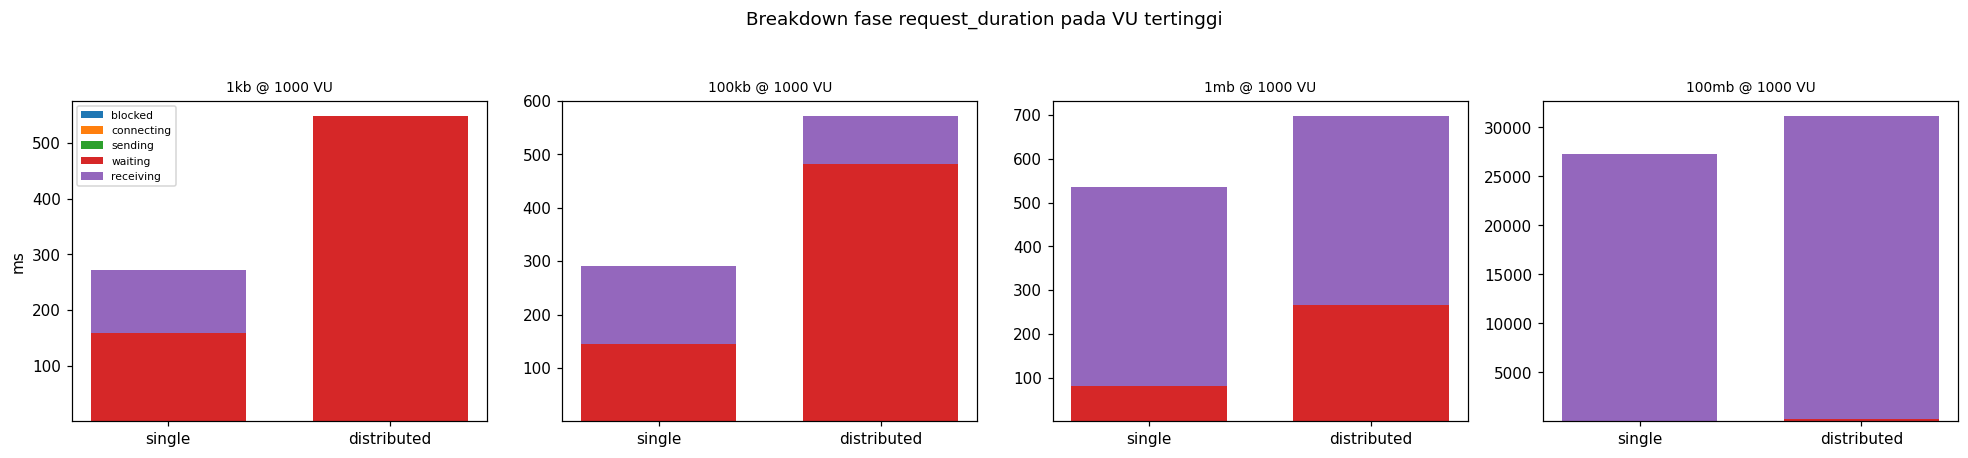

In [6]:
phase_cols = ["blocked_avg_ms", "connecting_avg_ms", "sending_avg_ms", "waiting_avg_ms", "receiving_avg_ms"]
phase_labels = ["blocked", "connecting", "sending", "waiting", "receiving"]
vus_levels = sorted(df["vus"].unique())

fig, axes = plt.subplots(1, len(size_order), figsize=(4.5 * len(size_order), 4.2), squeeze=False)
axes = axes[0]

for i, size in enumerate(size_order):
    ax = axes[i]
    sub = summary[(summary["size"] == size) & (summary["vus"] == max(vus_levels))]
    x = np.arange(len(mode_order))
    width = 0.7
    bottoms = np.zeros(len(mode_order))
    for phase_col, phase_label in zip(phase_cols, phase_labels):
        vals_phase = [sub[sub["mode"] == mo][phase_col].mean() for mo in mode_order]
        vals_phase = [0 if pd.isna(v) else v for v in vals_phase]
        ax.bar(x, vals_phase, width, bottom=bottoms, label=phase_label)
        bottoms += np.array(vals_phase)
    ax.set_xticks(x)
    ax.set_xticklabels(mode_order)
    ax.set_title(f"{size} @ {max(vus_levels)} VU", fontsize=9)
    ax.set_ylabel("ms" if i == 0 else "")
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle("Breakdown fase request_duration pada VU tertinggi", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

### 3b. Trend ukuran file & jumlah VU

In [7]:
# Konversi label ukuran file (mis. "100kb", "1mb") menjadi bytes, untuk sumbu-x yang proporsional & terurut benar
def size_to_bytes(s):
    s = s.lower().strip()
    num = float("".join(ch for ch in s if (ch.isdigit() or ch == ".")))
    if s.endswith("kb"):
        return num * 1024
    if s.endswith("mb"):
        return num * 1024 ** 2
    if s.endswith("gb"):
        return num * 1024 ** 3
    return num  # asumsikan sudah bytes / fallback

summary_trend = summary.copy()
summary_trend["size_bytes"] = summary_trend["size"].astype(str).map(size_to_bytes)
summary_trend = summary_trend.sort_values(["mode", "vus", "size_bytes"])

size_bytes_levels = sorted(summary_trend["size_bytes"].unique())
size_labels_sorted = (
    summary_trend[["size", "size_bytes"]]
    .drop_duplicates()
    .sort_values("size_bytes")["size"]
    .tolist()
)
print("Urutan ukuran file (kecil ke besar):", size_labels_sorted)

Urutan ukuran file (kecil ke besar): ['1kb', '100kb', '1mb', '100mb']


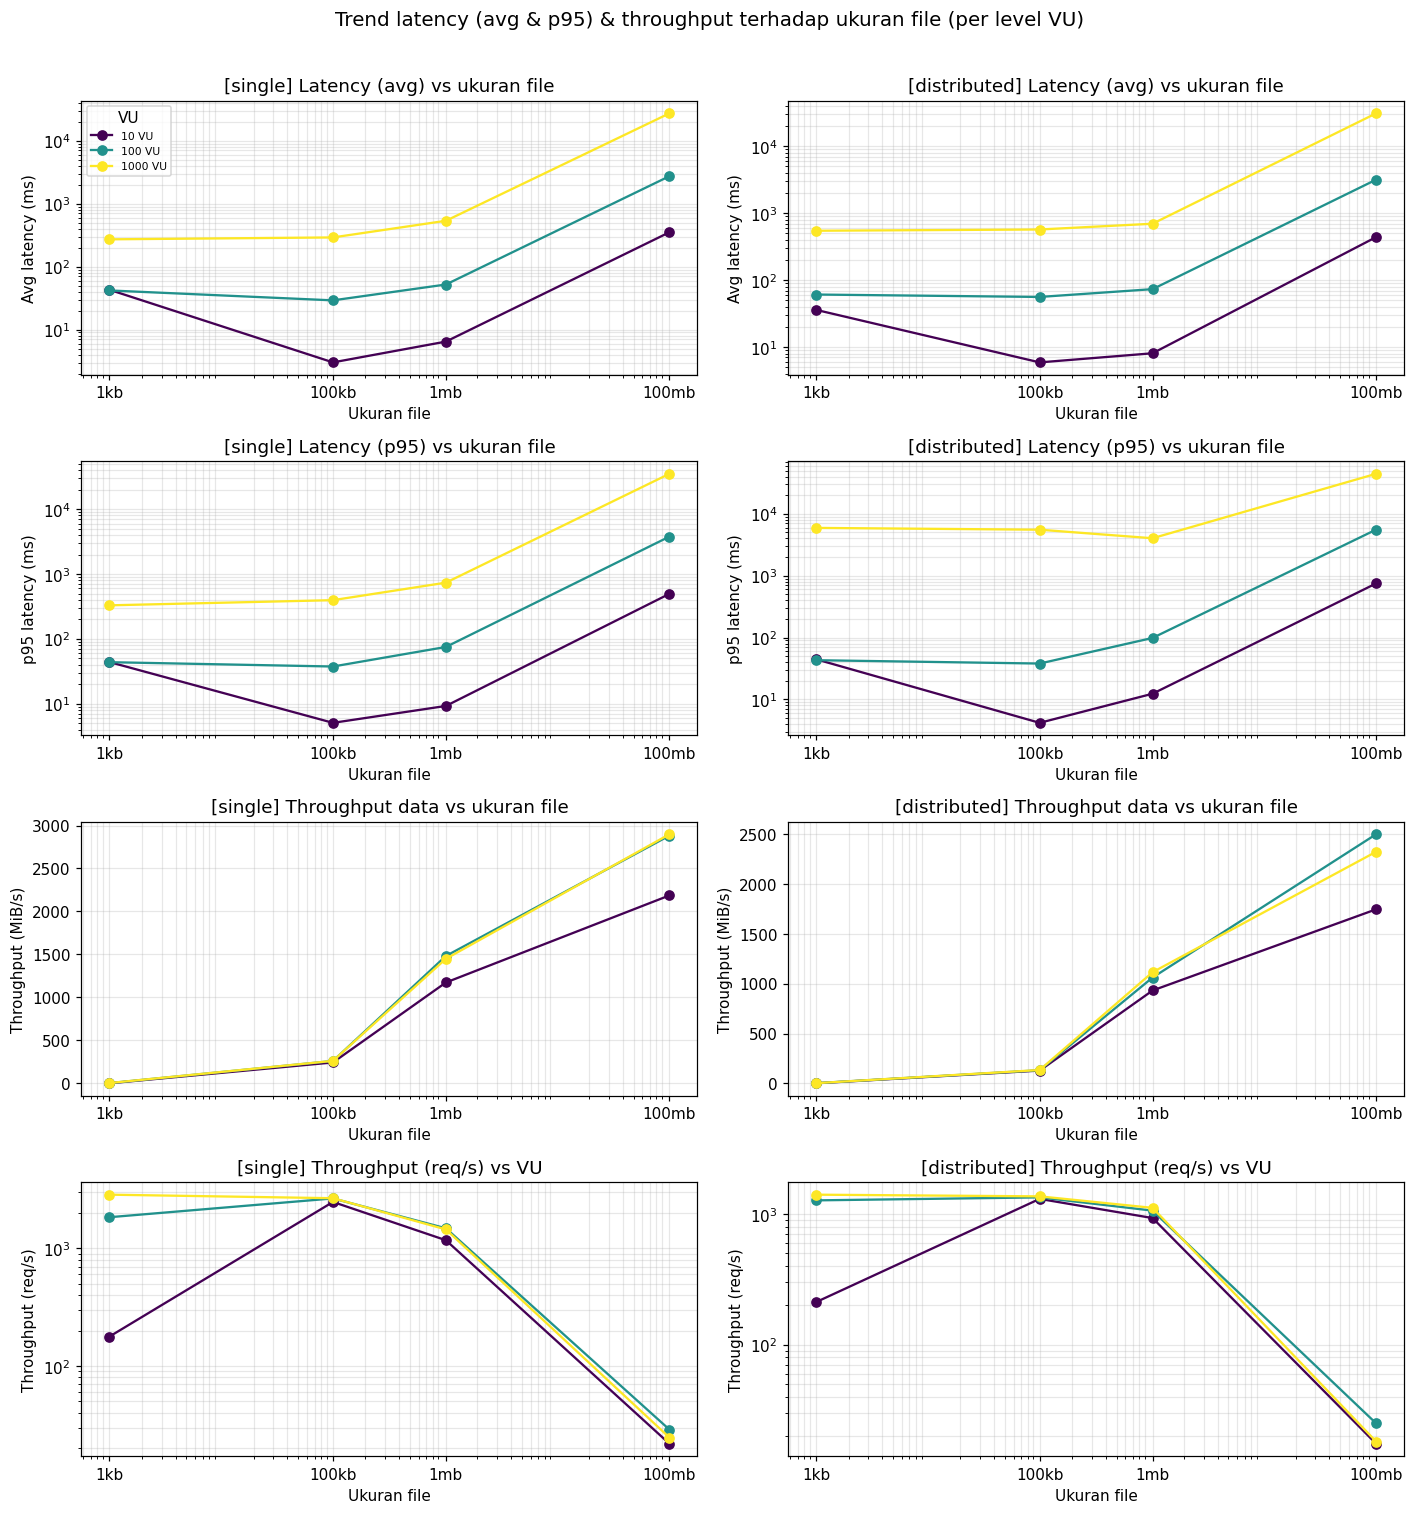

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(13, 14), squeeze=False)
cmap = plt.get_cmap("viridis")
vu_colors = {vu: cmap(i / max(len(vus_levels) - 1, 1)) for i, vu in enumerate(vus_levels)}

metric_rows = [
    ("avg_ms", "Avg latency (ms)", "Latency (avg) vs ukuran file"),
    ("p95_ms", "p95 latency (ms)", "Latency (p95) vs ukuran file"),
    ("MiB_s", "Throughput (MiB/s)", "Throughput data vs ukuran file"),
    ("req_s", "Throughput (req/s)", "Throughput (req/s) vs VU"),
]

for col, mode in enumerate(mode_order):
    sub_mode = summary_trend[summary_trend["mode"] == mode]

    for row, (metric, ylabel, title) in enumerate(metric_rows):
        ax = axes[row][col]
        for vu in vus_levels:
            s = sub_mode[sub_mode["vus"] == vu].sort_values("size_bytes")
            if s.empty:
                continue
            ax.plot(s["size_bytes"], s[metric], marker="o", color=vu_colors[vu], label=f"{vu} VU")
        ax.set_xscale("log")
        if metric != "MiB_s":
            ax.set_yscale("log")
        ax.set_xticks(size_bytes_levels)
        ax.set_xticklabels(size_labels_sorted, rotation=0)
        ax.set_xlabel("Ukuran file")
        ax.set_ylabel(ylabel)
        ax.set_title(f"[{mode}] {title}")
        ax.grid(alpha=0.3, which="both")
        if col == 0 and row == 0:
            ax.legend(fontsize=7, title="VU")

fig.suptitle("Trend latency (avg & p95) & throughput terhadap ukuran file (per level VU)", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## 4. Pembuktian Little's Law

In [ ]:
littles = summary.copy()
littles["L_measured"] = littles["vus_max"]
littles["W_s"] = littles["avg_ms"] / 1000.0
littles["lambda_req_s"] = littles["req_s"]
littles["L_predicted"] = littles["lambda_req_s"] * littles["W_s"]
littles["ratio_pred_over_measured"] = littles["L_predicted"] / littles["L_measured"]
littles["saturated"] = littles["ratio_pred_over_measured"] < 0.5

cols_show = ["size", "vus", "mode", "L_measured", "lambda_req_s", "W_s", "L_predicted", "ratio_pred_over_measured", "saturated"]
littles_display = littles[cols_show].sort_values(["size", "mode", "vus"])
littles_display.style.format({
    "L_measured": "{:.0f}",
    "lambda_req_s": "{:,.1f}",
    "W_s": "{:.4f}",
    "L_predicted": "{:,.2f}",
    "ratio_pred_over_measured": "{:.2%}",
}).background_gradient(subset=["ratio_pred_over_measured"], cmap="RdYlGn", vmin=0, vmax=1.2)

,size,vus,mode,L_measured,lambda_req_s,W_s,L_predicted,ratio_pred_over_measured,saturated
0,1kb,10,single,10,178.0,0.0429,7.64,76.42%,False
1,1kb,100,single,100,"1,840.1",0.0419,77.06,77.06%,False
2,1kb,1000,single,1000,"2,860.6",0.2716,776.91,77.69%,False
3,1kb,10,distributed,10,212.1,0.0360,7.64,76.41%,False
4,1kb,100,distributed,100,"1,273.1",0.0611,77.74,77.74%,False
5,1kb,1000,distributed,1000,"1,407.6",0.5484,771.89,77.19%,False
6,100kb,10,single,10,"2,480.8",0.0030,7.48,74.77%,False
7,100kb,100,single,100,"2,657.2",0.0291,77.43,77.43%,False
8,100kb,1000,single,1000,"2,669.3",0.2911,776.98,77.70%,False
9,100kb,10,distributed,10,"1,306.6",0.0059,7.73,77.27%,False


## 5. Estimasi Amdahl's Law

In [ ]:
amdahl = summary.pivot_table(index=["size", "vus"], columns="mode", values="req_s").reset_index()
amdahl = amdahl.dropna(subset=["single", "distributed"]) if "distributed" in amdahl.columns and "single" in amdahl.columns else amdahl

N_NODES = 3
amdahl["speedup_obs"] = amdahl["distributed"] / amdahl["single"]

def solve_P(S, N):
    if pd.isna(S) or S <= 0:
        return np.nan
    return (1 - 1 / S) / (1 - 1 / N)

amdahl["P_estimated"] = amdahl["speedup_obs"].apply(lambda s: solve_P(s, N_NODES))
amdahl["S_max_theoretical"] = amdahl["P_estimated"].apply(lambda p: 1 / (1 - p) if pd.notna(p) and p < 1 else np.nan)
amdahl["regime"] = np.select(
    [amdahl["speedup_obs"] > 1, amdahl["speedup_obs"] == 1, amdahl["speedup_obs"] < 1],
    ["scaling positif", "netral", "negative scaling (overhead dominan)"],
    default="n/a",
)

amdahl["size"] = pd.Categorical(amdahl["size"], categories=size_order, ordered=True)
amdahl = amdahl.sort_values(["size", "vus"]).reset_index(drop=True)

amdahl.style.format({
    "single": "{:,.1f}",
    "distributed": "{:,.1f}",
    "speedup_obs": "{:.3f}",
    "P_estimated": "{:.3f}",
    "S_max_theoretical": "{:.2f}",
}).background_gradient(subset=["speedup_obs"], cmap="RdYlGn", vmin=0.5, vmax=1.5)

mode,size,vus,single,distributed,speedup_obs,P_estimated,S_max_theoretical,regime
0,1kb,10,178.0,212.1,1.191,0.241,1.32,scaling positif
1,1kb,100,"1,840.1","1,273.1",0.692,-0.668,0.60,negative scaling (overhead dominan)
2,1kb,1000,"2,860.6","1,407.6",0.492,-1.548,0.39,negative scaling (overhead dominan)
3,100kb,10,"2,480.8","1,306.6",0.527,-1.348,0.43,negative scaling (overhead dominan)
4,100kb,100,"2,657.2","1,341.7",0.505,-1.471,0.40,negative scaling (overhead dominan)
5,100kb,1000,"2,669.3","1,366.5",0.512,-1.430,0.41,negative scaling (overhead dominan)
6,1mb,10,"1,173.0",932.1,0.795,-0.388,0.72,negative scaling (overhead dominan)
7,1mb,100,"1,481.6","1,062.3",0.717,-0.592,0.63,negative scaling (overhead dominan)
8,1mb,1000,"1,448.9","1,115.6",0.770,-0.448,0.69,negative scaling (overhead dominan)
9,100mb,10,21.9,17.5,0.799,-0.377,0.73,negative scaling (overhead dominan)


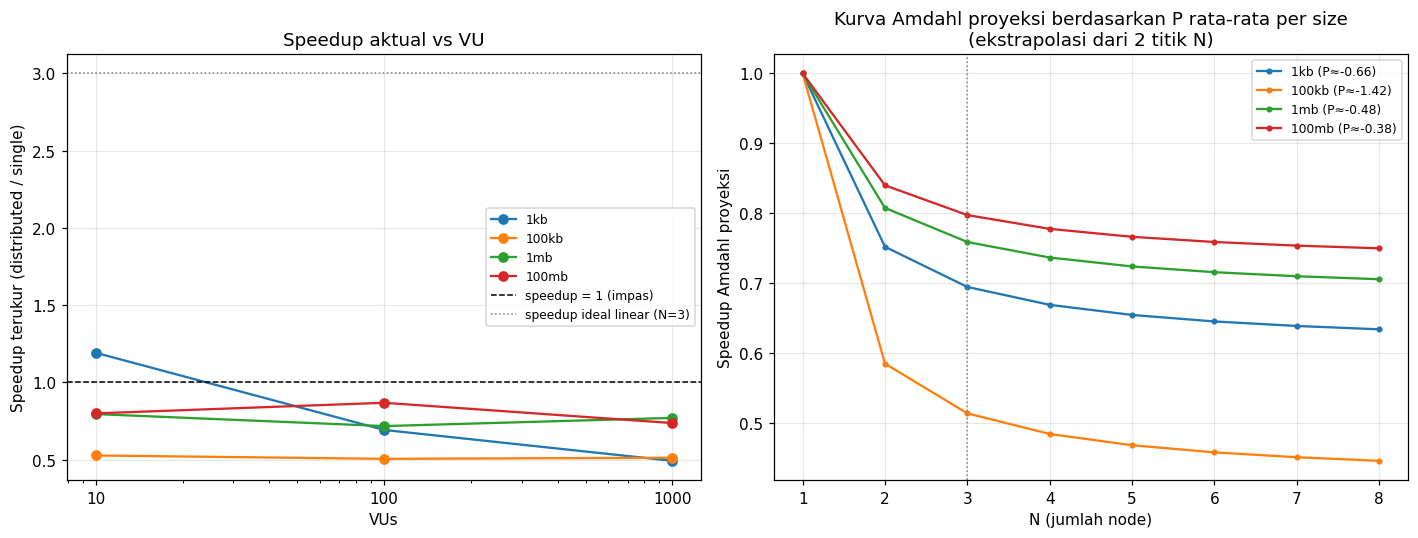

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for size in size_order:
    sub = amdahl[amdahl["size"] == size].sort_values("vus")
    if sub.empty:
        continue
    ax.plot(sub["vus"], sub["speedup_obs"], marker="o", label=size)
ax.axhline(1.0, color="k", linestyle="--", linewidth=1, label="speedup = 1 (impas)")
ax.axhline(N_NODES, color="gray", linestyle=":", linewidth=1, label=f"speedup ideal linear (N={N_NODES})")
ax.set_xscale("log")
ax.set_xticks(vus_levels)
ax.set_xticklabels(vus_levels)
ax.set_xlabel("VUs")
ax.set_ylabel("Speedup terukur (distributed / single)")
ax.set_title("Speedup aktual vs VU")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
n_range = np.arange(1, 9)
for size in size_order:
    sub = amdahl[amdahl["size"] == size]
    p_mean = sub["P_estimated"].mean()
    if pd.isna(p_mean):
        continue
    p_clipped = min(max(p_mean, -2), 0.999)
    s_curve = 1 / ((1 - p_clipped) + p_clipped / n_range)
    ax.plot(n_range, s_curve, marker=".", label=f"{size} (P≈{p_mean:.2f})")
ax.axvline(N_NODES, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("N (jumlah node)")
ax.set_ylabel("Speedup Amdahl proyeksi")
ax.set_title("Kurva Amdahl proyeksi berdasarkan P rata-rata per size\n(ekstrapolasi dari 2 titik N)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 6. Perbandingan langsung

In [ ]:
cmp = summary.pivot_table(index=["size", "vus"], columns="mode", values=["avg_ms", "req_s", "MiB_s"])
cmp.columns = [f"{a}_{b}" for a, b in cmp.columns]
cmp = cmp.reset_index()
cmp = cmp.dropna(subset=[c for c in cmp.columns if c.startswith("avg_ms_") or c.startswith("req_s_")])

cmp["latency_ratio_dist_over_single"] = cmp["avg_ms_distributed"] / cmp["avg_ms_single"]
cmp["throughput_ratio_dist_over_single"] = cmp["req_s_distributed"] / cmp["req_s_single"]

cmp["size"] = pd.Categorical(cmp["size"], categories=size_order, ordered=True)
cmp = cmp.sort_values(["size", "vus"]).reset_index(drop=True)

cmp[["size", "vus", "avg_ms_single", "avg_ms_distributed", "latency_ratio_dist_over_single",
     "req_s_single", "req_s_distributed", "throughput_ratio_dist_over_single"]].style.format({
    "avg_ms_single": "{:.2f}", "avg_ms_distributed": "{:.2f}", "latency_ratio_dist_over_single": "{:.2f}x",
    "req_s_single": "{:,.1f}", "req_s_distributed": "{:,.1f}", "throughput_ratio_dist_over_single": "{:.2f}x",
}).background_gradient(subset=["latency_ratio_dist_over_single"], cmap="RdBu_r", vmin=0.5, vmax=1.5
).background_gradient(subset=["throughput_ratio_dist_over_single"], cmap="RdYlGn", vmin=0.5, vmax=1.5)

,size,vus,avg_ms_single,avg_ms_distributed,latency_ratio_dist_over_single,req_s_single,req_s_distributed,throughput_ratio_dist_over_single
0,1kb,10,42.92,36.03,0.84x,178.0,212.1,1.19x
1,1kb,100,41.88,61.07,1.46x,"1,840.1","1,273.1",0.69x
2,1kb,1000,271.59,548.38,2.02x,"2,860.6","1,407.6",0.49x
3,100kb,10,3.01,5.91,1.96x,"2,480.8","1,306.6",0.53x
4,100kb,100,29.14,56.20,1.93x,"2,657.2","1,341.7",0.50x
5,100kb,1000,291.08,572.23,1.97x,"2,669.3","1,366.5",0.51x
6,1mb,10,6.45,8.10,1.26x,"1,173.0",932.1,0.79x
7,1mb,100,52.03,73.50,1.41x,"1,481.6","1,062.3",0.72x
8,1mb,1000,535.36,698.11,1.30x,"1,448.9","1,115.6",0.77x
9,100mb,10,352.09,440.85,1.25x,21.9,17.5,0.80x


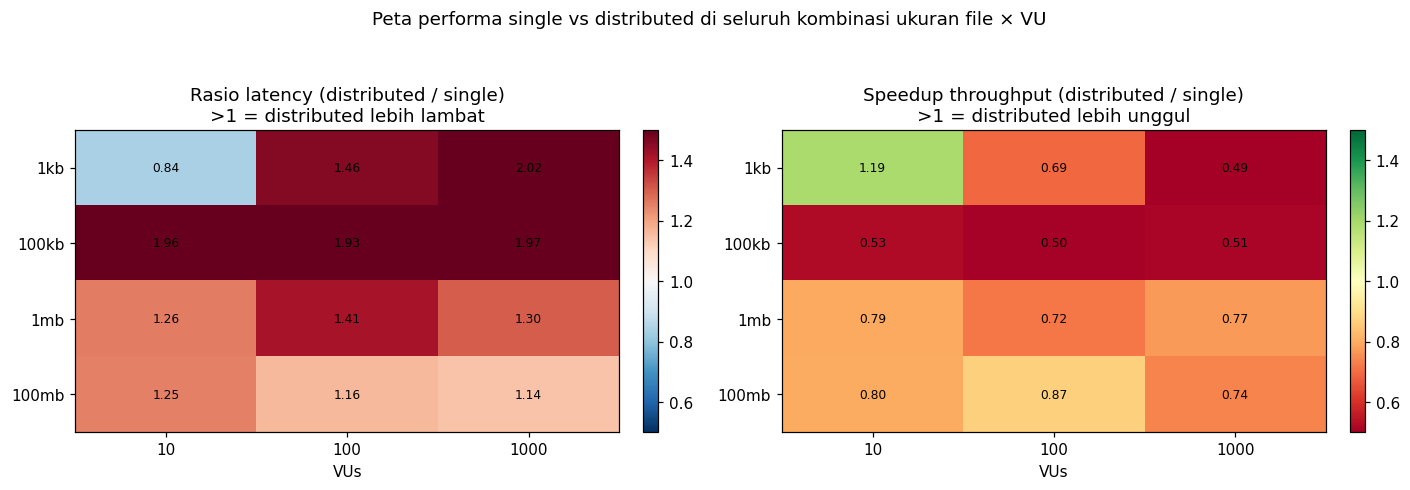

In [ ]:
lat_pivot = cmp.pivot(index="size", columns="vus", values="latency_ratio_dist_over_single").reindex(size_order)
thr_pivot = cmp.pivot(index="size", columns="vus", values="throughput_ratio_dist_over_single").reindex(size_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

im0 = axes[0].imshow(lat_pivot.values, cmap="RdBu_r", vmin=0.5, vmax=1.5, aspect="auto")
axes[0].set_xticks(range(len(lat_pivot.columns)))
axes[0].set_xticklabels(lat_pivot.columns)
axes[0].set_yticks(range(len(lat_pivot.index)))
axes[0].set_yticklabels(lat_pivot.index)
axes[0].set_xlabel("VUs")
axes[0].set_title("Rasio latency (distributed / single)\n>1 = distributed lebih lambat")
for i in range(lat_pivot.shape[0]):
    for j in range(lat_pivot.shape[1]):
        v = lat_pivot.values[i, j]
        if not np.isnan(v):
            axes[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(thr_pivot.values, cmap="RdYlGn", vmin=0.5, vmax=1.5, aspect="auto")
axes[1].set_xticks(range(len(thr_pivot.columns)))
axes[1].set_xticklabels(thr_pivot.columns)
axes[1].set_yticks(range(len(thr_pivot.index)))
axes[1].set_yticklabels(thr_pivot.index)
axes[1].set_xlabel("VUs")
axes[1].set_title("Speedup throughput (distributed / single)\n>1 = distributed lebih unggul")
for i in range(thr_pivot.shape[0]):
    for j in range(thr_pivot.shape[1]):
        v = thr_pivot.values[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle("Peta performa single vs distributed di seluruh kombinasi ukuran file × VU", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

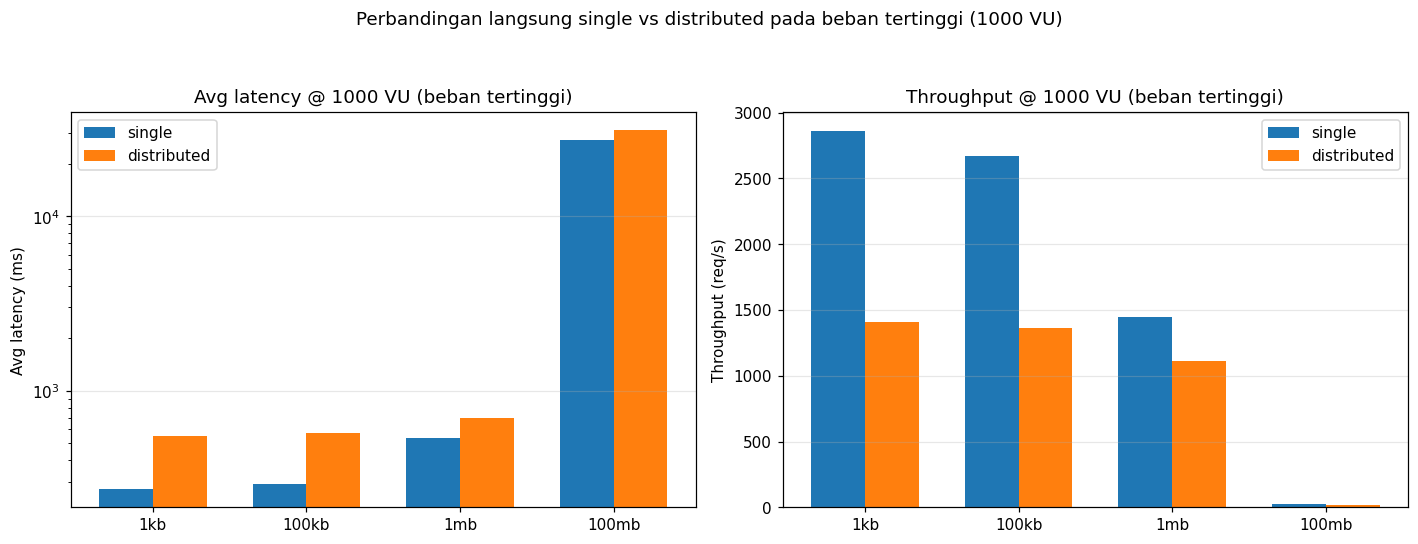

In [ ]:
max_vu = max(vus_levels)
bar_data = summary[summary["vus"] == max_vu].copy()
bar_data["size"] = pd.Categorical(bar_data["size"], categories=size_order, ordered=True)
bar_data = bar_data.sort_values(["size", "mode"])

x = np.arange(len(size_order))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i, mode in enumerate(mode_order):
    vals_m = [bar_data[(bar_data["size"] == sz) & (bar_data["mode"] == mode)]["avg_ms"].mean() for sz in size_order]
    ax.bar(x + (i - 0.5) * width, vals_m, width, label=mode)
ax.set_xticks(x)
ax.set_xticklabels(size_order)
ax.set_ylabel("Avg latency (ms)")
ax.set_yscale("log")
ax.set_title(f"Avg latency @ {max_vu} VU (beban tertinggi)")
ax.legend()
ax.grid(alpha=0.3, axis="y")

ax = axes[1]
for i, mode in enumerate(mode_order):
    vals_m = [bar_data[(bar_data["size"] == sz) & (bar_data["mode"] == mode)]["req_s"].mean() for sz in size_order]
    ax.bar(x + (i - 0.5) * width, vals_m, width, label=mode)
ax.set_xticks(x)
ax.set_xticklabels(size_order)
ax.set_ylabel("Throughput (req/s)")
ax.set_title(f"Throughput @ {max_vu} VU (beban tertinggi)")
ax.legend()
ax.grid(alpha=0.3, axis="y")

fig.suptitle(f"Perbandingan langsung single vs distributed pada beban tertinggi ({max_vu} VU)", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

=== Ringkasan headline: rata-rata dari SELURUH kondisi (semua size & VU digabung) ===


,avg_ms,req_s,MiB_s
mode,,,
single,2635.60,"1,405.4","1,070.18"
distributed,3069.97,839.8,840.13


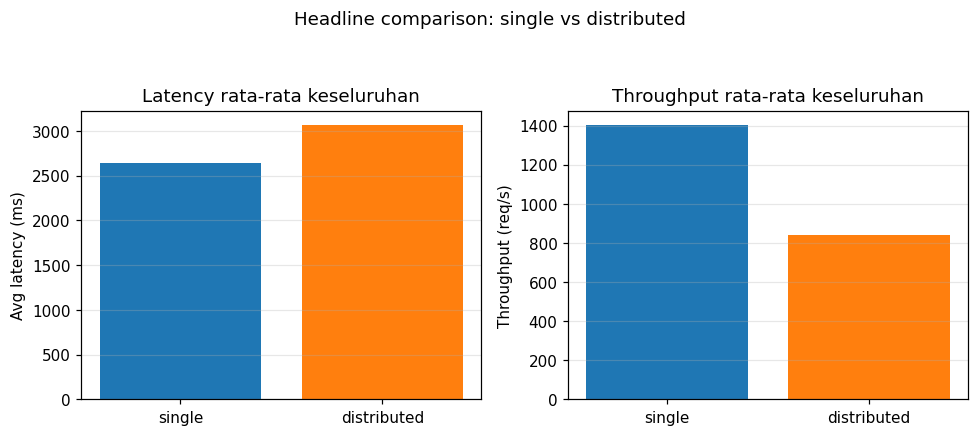

In [ ]:
headline = summary.groupby("mode")[["avg_ms", "req_s", "MiB_s"]].mean().reindex(mode_order)
print("=== Ringkasan headline: rata-rata dari SELURUH kondisi (semua size & VU digabung) ===")
display(headline.style.format({"avg_ms": "{:.2f}", "req_s": "{:,.1f}", "MiB_s": "{:,.2f}"}))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(mode_order, headline["avg_ms"], color=["tab:blue", "tab:orange"])
axes[0].set_ylabel("Avg latency (ms)")
axes[0].set_title("Latency rata-rata keseluruhan")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(mode_order, headline["req_s"], color=["tab:blue", "tab:orange"])
axes[1].set_ylabel("Throughput (req/s)")
axes[1].set_title("Throughput rata-rata keseluruhan")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle("Headline comparison: single vs distributed", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()